In [ ]:
%load_ext autoreload
%autoreload 2
import pandas as pd
import numpy as np
from collections import deque
from utils import lineage_name_mapping, load_json, bidict
from matplotlib import pyplot as plt
import matplotlib as mpl
mpl.rcParams['figure.dpi'] = 300
import seaborn as sns

from pareto_core import LineageOptimization, LineageTree

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


#### processing tracking data from Zhu Du's lab
https://www.cell.com/cell-reports/fulltext/S2211-1247(18)31982-X

In [205]:
lineage_data = load_json('./data/cell_lineage.json')
lineage_exp_df = pd.read_csv("data/protein/aggregated_all/s3_pca_10d.csv", index_col=0)
lineage_exp_df = lineage_exp_df.fillna(0)
tracking_df = pd.read_csv("data/more_embryo_du_lab/WT-EMB08.txt", sep="\t")
tracking_df.sort_values(by=["cell_name", "time"], inplace=True)
tracking_scale = 0.1625
untracked_nodes = ["P0", "AB", "P1"]
first_internal_layer = ["ABa", "ABp", "EMS", "P2"]

def depth_cutoff_func(depth):
    if depth <= 9:
        return 1
    else:
        return float('inf')

In [206]:
from collections import defaultdict
terminal_nodes = []
parent_dict = {}
terminal_parents_dict = defaultdict(list)
terminal_ancestry = defaultdict(list)
def dfs(node, parent, ancestors=[]):
    children = node.get("children", [])
    lookup_name = lineage_name_mapping(node["did"])
    if len(children) == 0:
        p_lookup_name = lineage_name_mapping(parent['did'])
        parent_dict[lookup_name] = p_lookup_name
        terminal_nodes.append(lookup_name)
        terminal_parents_dict[p_lookup_name].append(lookup_name)
        terminal_ancestry[lookup_name] = ancestors
    else:
        if parent is not None:
            p_lookup_name = lineage_name_mapping(parent['did'])
            parent_dict[lookup_name] = p_lookup_name
        for child in children:
            dfs(child, node, ancestors + [lookup_name])

dfs(lineage_data, None)

In [207]:
cell_type_df = pd.read_csv("data/2023-06-29_entropy_cell_key_V2.csv")
count = 0
lineage_type_code_dict = defaultdict(str)
type_code_dict = {}
na_lineages = []
for lineage in terminal_nodes:
    cur_cell_type_df = cell_type_df[cell_type_df['wormweb.lineage'] == lineage]
    if cur_cell_type_df.empty:
        # print(f"No cell types found for lineage: {lineage}")
        na_lineages.append(lineage)
        continue
    cur_lineage_types = cur_cell_type_df["wormweb.type"]
    # remove nan from cur_lineage_types
    cur_lineage_types = cur_lineage_types[~cur_lineage_types.isna()]
    cur_lineage_types = cur_lineage_types.unique()
    if len(cur_lineage_types) == 0:
        # print(f"No cell types found for lineage: {lineage}")
        na_lineages.append(lineage)
        continue
    cur_type = cur_lineage_types[0]
    if cur_type not in type_code_dict:
        # type_code_dict[cur_type] = chr(97 + len(type_code_dict))  # start from 'a'
        type_code_dict[cur_type] = len(type_code_dict)
    lineage_type_code_dict[lineage] = type_code_dict[cur_type]
# dead/NA type
na_type_code = len(type_code_dict)
type_code_dict["dead/NA"] = na_type_code # unknown/dead type
for lineage in na_lineages:
    lineage_type_code_dict[lineage] = na_type_code

In [208]:
complexity_code_dict = {}
cell_div_count = 0
parent_code_mapping = {}
for node in terminal_nodes:
    complexity_code_dict[node] = lineage_type_code_dict[node]
bfs_queue = deque(terminal_nodes)
while bfs_queue:
    cur_node = bfs_queue.popleft()
    cur_parent = parent_dict.get(cur_node, None)
    cur_node_code = complexity_code_dict.get(cur_node, None)
    if cur_node_code is None:
        print(f"Type code not found for node: {cur_node}")
        continue
    if cur_parent is None:
        print(f"Parent not found for node: {cur_node}")
        continue
    if cur_parent not in complexity_code_dict:
        complexity_code_dict[cur_parent] = cur_node_code
        bfs_queue.append(cur_parent)
    else:
        cur_parent_code = complexity_code_dict[cur_parent]
        if cur_parent_code > cur_node_code:
            parent_code_tuple = (cur_parent_code, cur_node_code)
        else:
            parent_code_tuple = (cur_node_code, cur_parent_code)
        if parent_code_tuple not in parent_code_mapping:
            parent_code_mapping[parent_code_tuple] = len(parent_code_mapping)+len(type_code_dict)
        complexity_code_dict[cur_parent] = parent_code_mapping[parent_code_tuple]
        cell_div_count += 1

    

Parent not found for node: P0


In [209]:
cell_names = tracking_df["cell_name"].unique()
lineage_xyz_df = pd.DataFrame(columns=["x", "y", "z"])
lineage_name_to_last_tracking_time = {}
for name in cell_names:
    time_points = tracking_df.loc[tracking_df['cell_name'] == name]["time"].values
    lineage_tracks = tracking_df.loc[tracking_df['cell_name'] == name]
    last_xyz_coordinates = lineage_tracks[["X", "Y", "Z"]].values[-1]
    last_tracking_time = lineage_tracks["time"].values[-1]
    lineage_name_to_last_tracking_time[name] = int(last_tracking_time)
    lineage_xyz_df.loc[name] = last_xyz_coordinates
# Z coordinate needs to be scaled by 4.5 to account for different imaging resolution
lineage_xyz_df["z"] = lineage_xyz_df["z"] * 4.5

In [210]:
common_lineages = lineage_xyz_df.index.intersection(lineage_exp_df.index)
for name in untracked_nodes:
    lineage_xyz_df.loc[name] = np.repeat(np.nan, 3)
    lineage_exp_df.loc[name] = np.repeat(np.nan, lineage_exp_df.shape[1])
common_lineages = untracked_nodes + common_lineages.tolist()
lineage_id_to_last_tracking_time = [-1] * len(common_lineages)
for idx, name in enumerate(common_lineages):
    lineage_id_to_last_tracking_time[idx] = lineage_name_to_last_tracking_time.get(name, -1)
    if lineage_name_to_last_tracking_time.get(name, -1) == -1:
        print(f"Warning: No last tracking time for lineage {name}")

In [211]:
lineage_tree = LineageTree()
# add first three nodes: ["AB", "P0", "P1"]
missing_first_nodes = ["P0", "AB", "P1"]
lineage_tree.add_node(0, -1)
lineage_tree.root = 0
lineage_tree.add_node(1, 0)
lineage_tree.add_node(2, 0)
bfs_queue = deque()
bfs_queue.append((lineage_data, -1))
while bfs_queue:
    node, parent_idx = bfs_queue.popleft()
    curr_name = lineage_name_mapping(node['did'])
    if curr_name not in common_lineages:
        continue
    curr_idx = common_lineages.index(curr_name)
    if curr_idx >= 3:
        parent_idx = lineage_tree.reverse_lineage_id_mapping[parent_idx]
        lineage_tree.add_node(curr_idx, parent_idx)
    children = node.get('children', [])
    for child_node in children:
        bfs_queue.append((child_node, curr_idx))
lineage_tree.record_last_tracked_time(lineage_id_to_last_tracking_time)

print("first layer of tracked nodes:", lineage_tree.children_list[1]+lineage_tree.children_list[2])

first layer of tracked nodes: [3, 4, 5, 6]


In [212]:
lineage_xyz_mat = lineage_xyz_df.loc[common_lineages].values
lineage_exp_mat = lineage_exp_df.loc[common_lineages].values

In [213]:
first_layer = [(3,2), (4,2), (5,2), (6,2)]
# first_layer = [(5,2)]

opt = LineageOptimization(
    lineage_xyz_mat, 
    lineage_exp_mat,
    lineage_tree,
    first_internal_layer=first_layer,
    lineage_names=common_lineages, 
    lineage_type_code_dict=complexity_code_dict,
    exp_norm=2)

16802.698033096516 69365.50123405324 720
Complexity Score of the original lineage tree: 0.22865013774104684


In [214]:
pareto_list_by_layer = opt.bottom_up_by_layer_runner()
pareto_list_top_down_rebuild = opt.top_down_rebuild_runner()
pareto_mst_list = opt.mst_rebuild_runner()
pareto_list_top_down_rebuild_depth_cutoff = opt.top_down_rebuild_runner(depth_weight_type=depth_cutoff_func)

pareto_xyz_cost_list_by_layer = [cost[0] for cost in pareto_list_by_layer]
pareto_exp_cost_list_by_layer = [cost[1] for cost in pareto_list_by_layer]
pareto_xyz_cost_list_top_down_rebuild = [cost[0] for cost in pareto_list_top_down_rebuild]
pareto_exp_cost_list_top_down_rebuild = [cost[1] for cost in pareto_list_top_down_rebuild]
pareto_xyz_cost_list_mst = [cost[0] for cost in pareto_mst_list]
pareto_exp_cost_list_mst = [cost[1] for cost in pareto_mst_list]
pareto_xyz_cost_list_top_down_rebuild_depth_cutoff = [cost[0] for cost in pareto_list_top_down_rebuild_depth_cutoff]
pareto_exp_cost_list_top_down_rebuild_depth_cutoff = [cost[1] for cost in pareto_list_top_down_rebuild_depth_cutoff]

Computing pareto costs:   0%|          | 0/1001 [00:00<?, ?it/s]

Computing pareto costs:   0%|          | 0/1001 [00:00<?, ?it/s]

Computing mst test:   0%|          | 0/1001 [00:00<?, ?it/s]

Error: leaf openings less than required
Error: leaf openings less than required
Error: leaf openings less than required
Error: leaf openings less than required
Error: leaf openings less than required
Error: leaf openings less than required
Error: leaf openings less than required
Error: leaf openings less than required
Error: leaf openings less than required
Error: leaf openings less than required
Error: leaf openings less than required
Error: leaf openings less than required
Error: leaf openings less than required
Error: leaf openings less than required
Error: leaf openings less than required
Error: leaf openings less than required
Error: leaf openings less than required
Error: leaf openings less than required
Error: leaf openings less than required
Error: leaf openings less than required
Error: leaf openings less than required
Error: leaf openings less than required
Error: leaf openings less than required
Error: leaf openings less than required
Error: leaf openings less than required


Computing pareto costs:   0%|          | 0/1001 [00:00<?, ?it/s]

In [215]:
pareto_list_paired_bottom_up_rebuild = opt.paired_bottom_up_rebuild_runner()
pareto_xyz_cost_list_paired_bottom_up_rebuild = [cost[0] for cost in pareto_list_paired_bottom_up_rebuild]
pareto_exp_cost_list_paired_bottom_up_rebuild = [cost[1] for cost in pareto_list_paired_bottom_up_rebuild]

Computing pareto costs 1/4:   0%|          | 0/250 [00:00<?, ?it/s]

Computing pareto costs 2/4:   0%|          | 0/250 [00:00<?, ?it/s]

Computing pareto costs 3/4:   0%|          | 0/250 [00:00<?, ?it/s]

Computing pareto costs 4/4:   0%|          | 0/251 [00:00<?, ?it/s]

In [216]:
pareto_list_terminal_only_kd_internal = opt.terminal_only_rebuild_runner(use_kd_tree=True)
pareto_xyz_cost_list_terminal_only_kd_internal = [cost[0] for cost in pareto_list_terminal_only_kd_internal]
pareto_exp_cost_list_terminal_only_kd_internal = [cost[1] for cost in pareto_list_terminal_only_kd_internal]


Computing pareto costs 1/2:   0%|          | 0/500 [00:00<?, ?it/s]

Computing pareto costs 2/2:   0%|          | 0/501 [00:00<?, ?it/s]

In [217]:
phylogeny_sample_xyz_cost, phylogeny_sample_exp_cost, phylogeny_mean_xyz_cost, phylogeny_mean_exp_cost = opt.phylogenetic_sampling(n_samples=100000)

In [218]:
best_compexity_lineage_parent_list,complexity_optimization_cost_list, best_complexity_score = opt.genetic_complexity_optimization(iterations=1000000)
xyz_cost_complexity_optimization = [cost[0] for cost in complexity_optimization_cost_list]
exp_cost_complexity_optimization = [cost[1] for cost in complexity_optimization_cost_list]
min_complexity_xyz_cost = xyz_cost_complexity_optimization[-1]
min_complexity_exp_cost = exp_cost_complexity_optimization[-1]

Initial Complexity Score: 0.22865013774104684


  0%|          | 0/1000000 [00:00<?, ?it/s]

100%|██████████| 1000000/1000000 [04:41<00:00, 3557.52it/s]


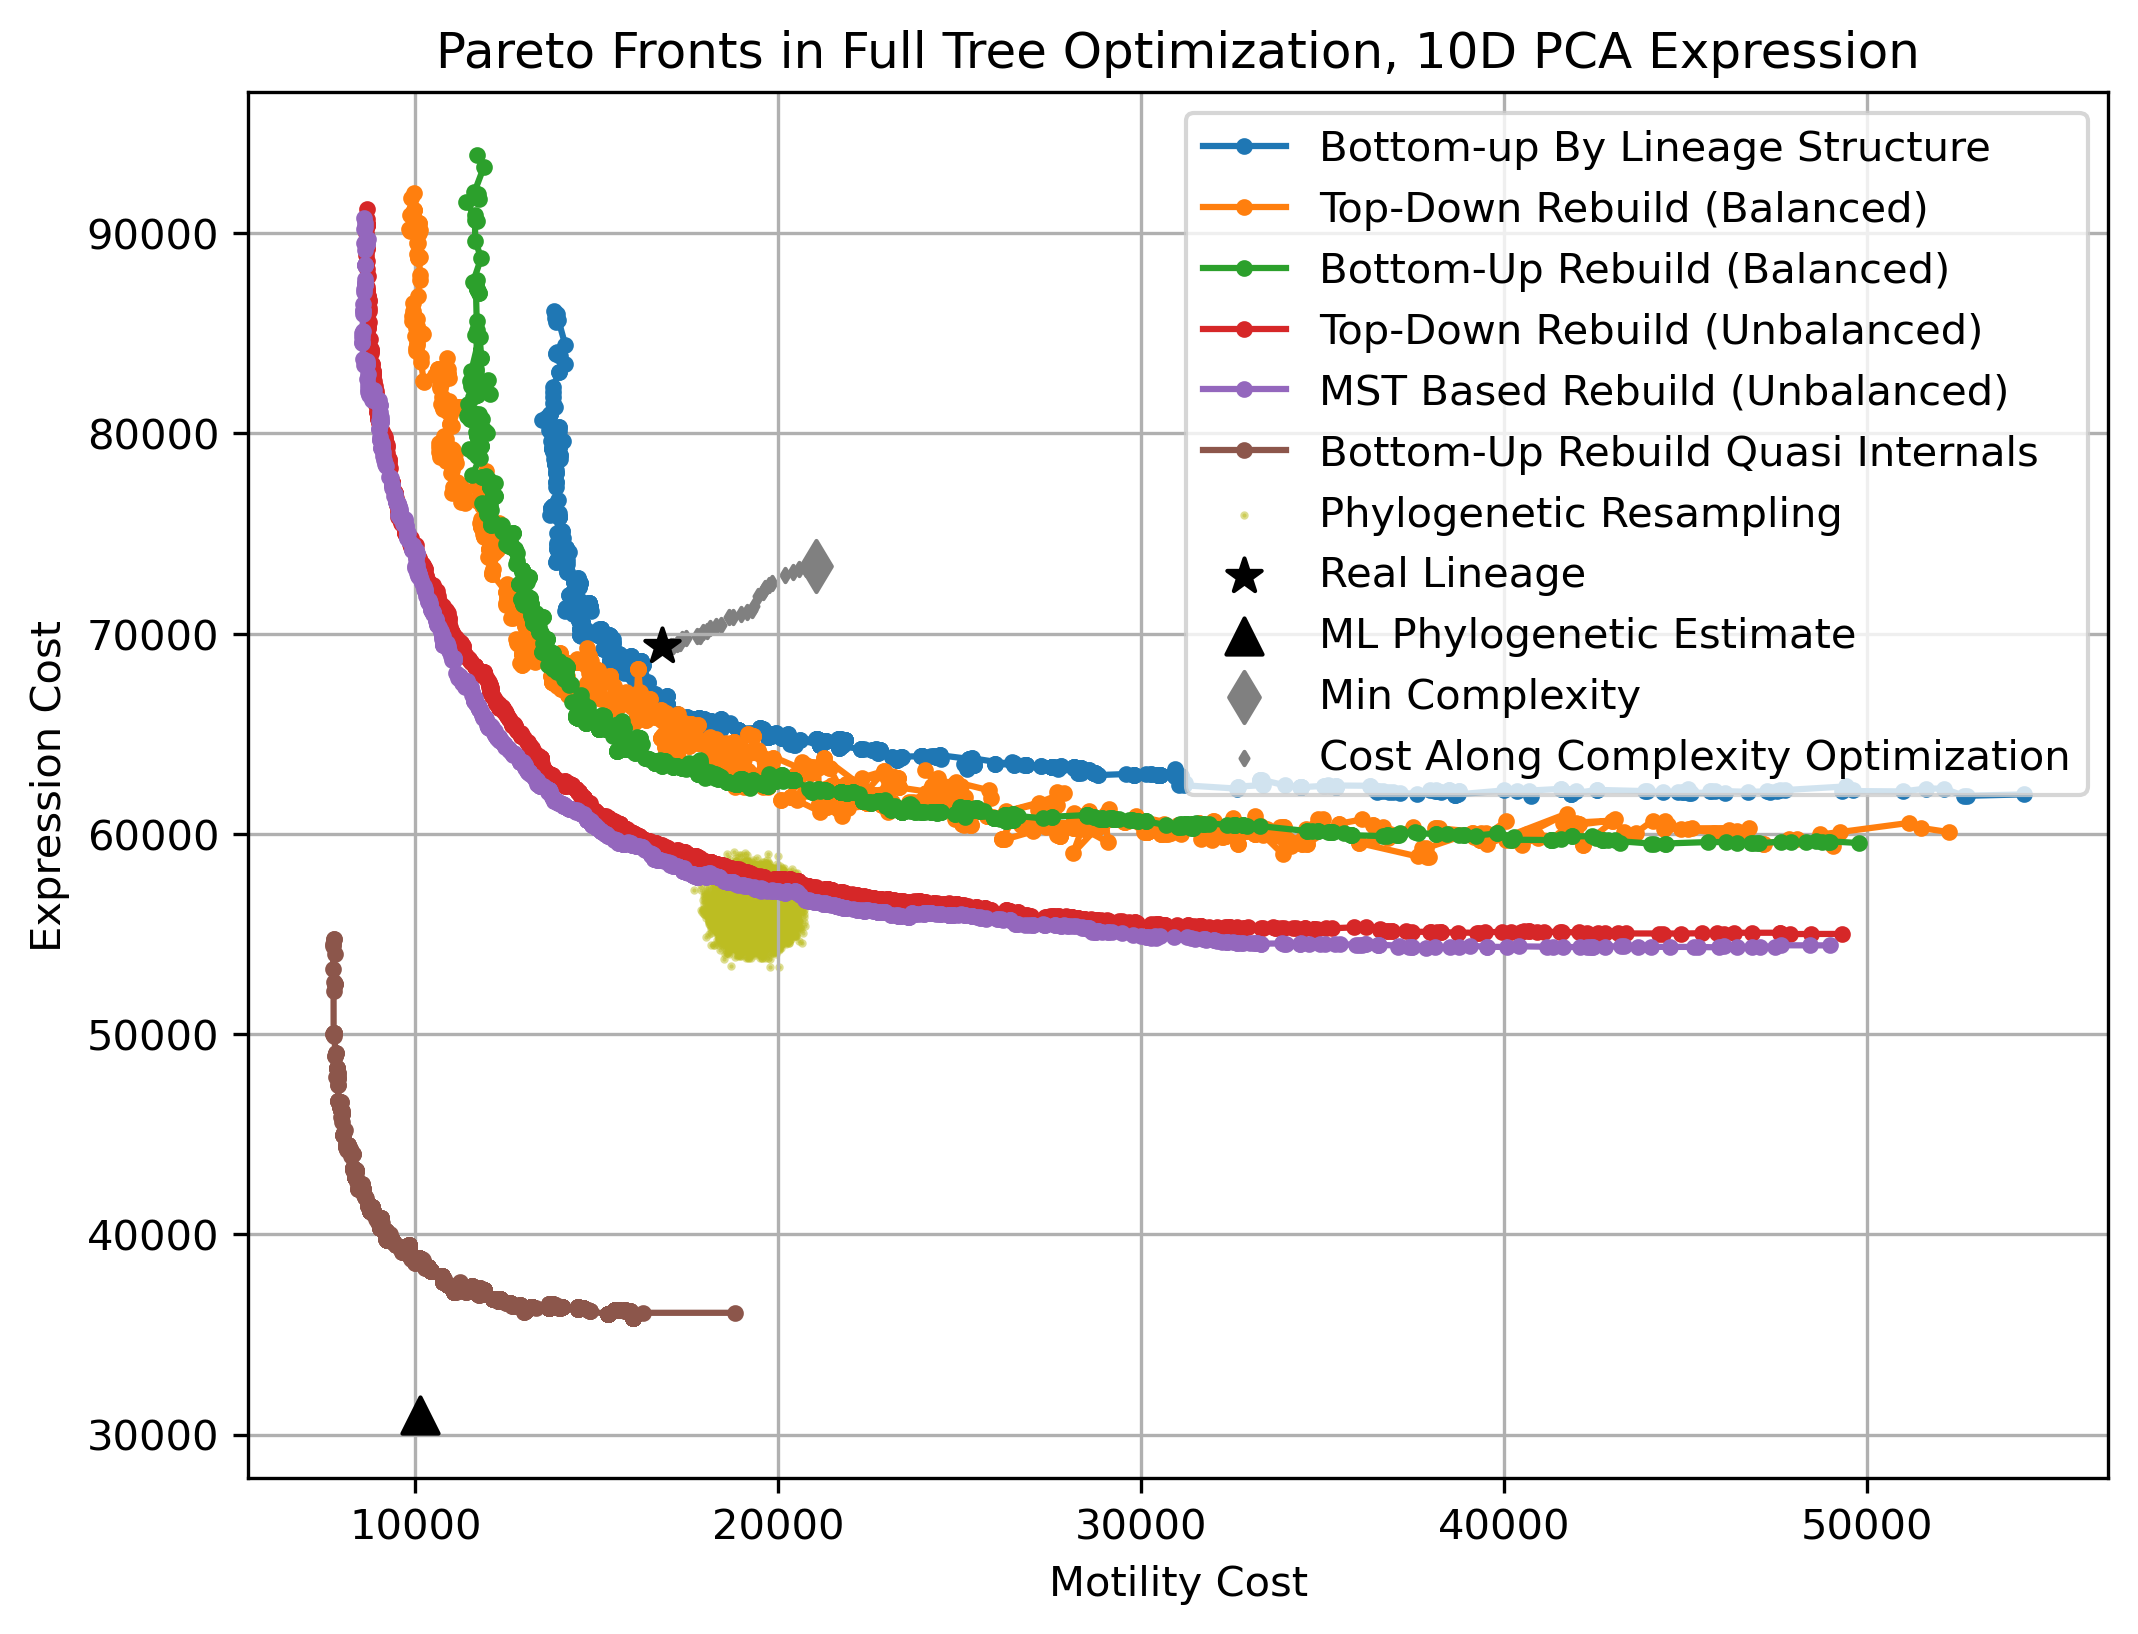

In [220]:
colors = sns.color_palette(n_colors=10)
plt.figure(figsize=(8, 6))
plt.plot(pareto_xyz_cost_list_by_layer, pareto_exp_cost_list_by_layer, marker='o', linestyle='-',  markersize=3, label='Bottom-up By Lineage Structure')
plt.plot(pareto_xyz_cost_list_top_down_rebuild_depth_cutoff, pareto_exp_cost_list_top_down_rebuild_depth_cutoff, marker='o', linestyle='-', markersize=3, label='Top-Down Rebuild (Balanced)')
plt.plot(pareto_xyz_cost_list_paired_bottom_up_rebuild, pareto_exp_cost_list_paired_bottom_up_rebuild, marker='o', linestyle='-', markersize=3, label='Bottom-Up Rebuild (Balanced)')
plt.plot(pareto_xyz_cost_list_top_down_rebuild, pareto_exp_cost_list_top_down_rebuild, marker='o', linestyle='-',  markersize=3, label='Top-Down Rebuild (Unbalanced)')
plt.plot(pareto_xyz_cost_list_mst, pareto_exp_cost_list_mst, marker='o', linestyle='-',  markersize=3, label='MST Based Rebuild (Unbalanced)')
plt.plot(pareto_xyz_cost_list_terminal_only_kd_internal, pareto_exp_cost_list_terminal_only_kd_internal, marker='o', linestyle='-', markersize=3, label='Bottom-Up Rebuild Quasi Internals')
plt.scatter(phylogeny_sample_xyz_cost, phylogeny_sample_exp_cost, alpha=0.5, s=1, color=colors[8], label='Phylogenetic Resampling')
plt.scatter(opt.lineage_xyz_cost, opt.lineage_exp_cost, color='black', marker='*', label='Real Lineage', zorder=99, s=75)
plt.scatter(phylogeny_mean_xyz_cost, phylogeny_mean_exp_cost, color='black', marker='^', label='ML Phylogenetic Estimate', zorder=99, s=75)
plt.scatter(min_complexity_xyz_cost, min_complexity_exp_cost, color='grey', marker='d', label='Min Complexity', zorder=99, s=75)
plt.scatter(xyz_cost_complexity_optimization, exp_cost_complexity_optimization, color='grey', marker='d', label='Cost Along Complexity Optimization', s=5)
plt.xlabel('Motility Cost')
plt.ylabel('Expression Cost')
plt.title(f'Pareto Fronts in Full Tree Optimization, 10D PCA Expression')
plt.grid(True)
plt.legend()
plt.show()

In [221]:
results_df = pd.DataFrame({
    'Bottom-up By Layer XYZ Cost': pareto_xyz_cost_list_by_layer,
    'Bottom-up By Layer Exp Cost': pareto_exp_cost_list_by_layer,
    'Top-Down Rebuild XYZ Cost': pareto_xyz_cost_list_top_down_rebuild,
    'Top-Down Rebuild Exp Cost': pareto_exp_cost_list_top_down_rebuild,
    'Paired Bottom-Up Rebuild XYZ Cost': pareto_xyz_cost_list_paired_bottom_up_rebuild,
    'Paired Bottom-Up Rebuild Exp Cost': pareto_exp_cost_list_paired_bottom_up_rebuild,
    'MST Based Rebuild XYZ Cost': pareto_xyz_cost_list_mst,
    'MST Based Rebuild Exp Cost': pareto_exp_cost_list_mst,
    'Top-Down Rebuild (Hard Depth Cutoff) XYZ Cost': pareto_xyz_cost_list_top_down_rebuild_depth_cutoff,
    'Top-Down Rebuild (Hard Depth Cutoff) Exp Cost': pareto_exp_cost_list_top_down_rebuild_depth_cutoff
})
results_df.to_csv('output/du_tracking/08/pareto_comparison.csv', index=False)

In [222]:
# save pareto_list_terminal_only_kd_internal as a pandas dataframe
pareto_df_terminal_only_kd_internal = pd.DataFrame(pareto_list_terminal_only_kd_internal, columns=['xyz_cost', 'exp_cost', 'internal_selection_count', 'complexity_score', 'min_consines', 'mean_consines'])
pareto_df_terminal_only_kd_internal.to_csv('output/du_tracking/08/pareto_terminal_only_kd_internal.tsv', index=False, sep='\t')